In [2]:
!pip install transformers datasets torch scikit-learn mlflow --break-system-packages

  Using cached transformers-5.12.1-py3-none-any.whl.metadata (33 kB)
  Using cached datasets-5.0.0-py3-none-any.whl.metadata (23 kB)
  Using cached mlflow-3.14.0-py3-none-any.whl.metadata (49 kB)
  Using cached huggingface_hub-1.20.1-py3-none-any.whl.metadata (14 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached typer-0.26.7-py3-none-any.whl.metadata (16 kB)
  Using cached safetensors-0.8.0-cp310-abi3-macosx_11_0_arm64.whl.metadata (4.2 kB)
  Using cached click-8.4.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached hf_xet-1.5.1-cp37-abi3-macosx_11_0_arm64.whl.metadata (4.9 kB)
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached dill-0.4.1-py3-none-any.whl.metadata (10 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mlflow_skinny-3.14.0-p

In [1]:
import torch
import transformers
import mlflow
print(torch.__version__, transformers.__version__, mlflow.__version__)
print(torch.backends.mps.is_available())

2.12.1 5.12.1 3.14.0
True


In [2]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split

# Veriyi yükle
df = pd.read_csv('/Users/erenbey/amazon-fine-food-reviews/balanced_reviews.csv')

# Label encoding
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['sentiment'].map(label_map)

# Text alanını hazırla
df['text'] = df['Text'].astype(str)

# Train/val/test split (%80/%10/%10)
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print('Train:', len(train_df))
print('Val:', len(val_df))
print('Test:', len(test_df))

train_df.head(3)

Train: 96000
Val: 12000
Test: 12000


,Id,ProductId,Time,Score,sentiment,Summary,Text,label,text
80060,206299,B003CGJGK4,1340064000,4,positive,Doesn't fit in bags-on-board style dog bag dis...,My singular complaint is that these bags don't...,2,My singular complaint is that these bags don't...
60528,43494,B001EQ4P2I,1297036800,5,positive,Best Nuts Ever,I absolutely love these nuts! I can't find the...,2,I absolutely love these nuts! I can't find the...
112154,260135,B000NMJWZO,1323302400,5,positive,life saver!,We love Pamelas products in our home. They ha...,2,We love Pamelas products in our home. They ha...


In [3]:
from transformers import DistilBertTokenizerFast
import torch
from torch.utils.data import Dataset

# Tokenizer yükle
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# Custom Dataset class
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Dataset objelerini oluştur
train_dataset = SentimentDataset(train_df['text'], train_df['label'], tokenizer)
val_dataset = SentimentDataset(val_df['text'], val_df['label'], tokenizer)
test_dataset = SentimentDataset(test_df['text'], test_df['label'], tokenizer)

print('Train dataset size:', len(train_dataset))

# Bir örneğe bakalım
sample = train_dataset[0]
print('Input IDs shape:', sample['input_ids'].shape)
print('Attention mask shape:', sample['attention_mask'].shape)
print('Label:', sample['labels'])

Train dataset size: 96000
Input IDs shape: torch.Size([256])
Attention mask shape: torch.Size([256])
Label: tensor(2)


In [7]:
from transformers import DistilBertForSequenceClassification, TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

# Model yükle (3 sınıf: negative, neutral, positive)
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3
)

# Cihazı ayarla (M1 Pro için MPS)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.to(device)
print('Using device:', device)

# Metrik hesaplama fonksiyonu
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
    acc = accuracy_score(labels, predictions)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Eğitim ayarları
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    report_to='none'  # MLflow'u manuel entegre edeceğiz
)

# Trainer oluştur
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print('Trainer hazır, eğitime başlanabilir.')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

KeyboardInterrupt: 

In [4]:
from transformers import DistilBertForSequenceClassification, TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

# Model yükle (3 sınıf: negative, neutral, positive)
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3
)

# Cihazı ayarla (M1 Pro için MPS)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.to(device)
print('Using device:', device)

# Metrik hesaplama fonksiyonu
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
    acc = accuracy_score(labels, predictions)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Eğitim ayarları
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    report_to='none'  # MLflow'u manuel entegre edeceğiz
)

# Trainer oluştur
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print('Trainer hazır, eğitime başlanabilir.')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Using device: mps
Trainer hazır, eğitime başlanabilir.


In [9]:
!pip install accelerate --break-system-packages


In [5]:
trainer.train()

/opt/anaconda3/envs/tf-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [6]:
sample_lengths = train_df['text'].str[:500].apply(lambda x: len(tokenizer.encode(str(x))))
print('Mean token length:', sample_lengths.mean())
print('Median:', sample_lengths.median())
print('95th percentile:', sample_lengths.quantile(0.95))
print('Max:', sample_lengths.max())

Mean token length: 82.82805208333333
Median: 82.0
95th percentile: 134.0
Max: 238


In [7]:
# Dataset'leri yeni max_length ile yeniden oluştur
train_dataset = SentimentDataset(train_df['text'], train_df['label'], tokenizer, max_length=128)
val_dataset = SentimentDataset(val_df['text'], val_df['label'], tokenizer, max_length=128)
test_dataset = SentimentDataset(test_df['text'], test_df['label'], tokenizer, max_length=128)

# Modeli sıfırdan yükle (önceki kısmi eğitim ağırlıklarını temizlemek için)
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3
)
model.to(device)

# Trainer'ı yeniden oluştur
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print('Dataset ve Trainer 128 token ile yeniden hazırlandı.')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Dataset ve Trainer 128 token ile yeniden hazırlandı.


In [8]:
trainer.train()

/opt/anaconda3/envs/tf-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.494396,0.498220,0.800250,0.799744,0.800037,0.800250
2,0.391147,0.461542,0.826583,0.825652,0.826252,0.826583
3,0.178271,0.583846,0.832667,0.833266,0.834155,0.832667


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/anaconda3/envs/tf-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/anaconda3/envs/tf-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=18000, training_loss=0.3967590691248576, metrics={'train_runtime': 8431.658, 'train_samples_per_second': 34.157, 'train_steps_per_second': 2.135, 'total_flos': 9537822793728000.0, 'train_loss': 0.3967590691248576, 'epoch': 3.0})

In [9]:
trainer.save_model('./final_model')
tokenizer.save_pretrained('./final_model')
print('Model ve tokenizer kaydedildi.')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model ve tokenizer kaydedildi.


In [10]:
from torch.utils.data import DataLoader

test_loader = DataLoader(test_dataset, batch_size=32)

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels']

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print('Tahmin tamamlandı, toplam:', len(all_preds))

Tahmin tamamlandı, toplam: 12000


In [12]:
from sklearn.metrics import classification_report, confusion_matrix

In [13]:
label_names = ['negative', 'neutral', 'positive']

print(classification_report(all_labels, all_preds, target_names=label_names))
print()
print('Confusion Matrix:')
print(confusion_matrix(all_labels, all_preds))

              precision    recall  f1-score   support

    negative       0.85      0.84      0.84      4000
     neutral       0.77      0.79      0.78      4000
    positive       0.90      0.87      0.88      4000

    accuracy                           0.84     12000
   macro avg       0.84      0.84      0.84     12000
weighted avg       0.84      0.84      0.84     12000


Confusion Matrix:
[[3371  533   96]
 [ 525 3162  313]
 [  88  419 3493]]


In [14]:
import pandas as pd

# Orijinal tüm veriyi yükle (568K satır)
full_df = pd.read_csv('/Users/erenbey/amazon-fine-food-reviews/Reviews.csv')
full_df['date'] = pd.to_datetime(full_df['Time'], unit='s')

print('Toplam satır:', len(full_df))
print('Tarih aralığı:', full_df['date'].min(), '-', full_df['date'].max())

Toplam satır: 568454
Tarih aralığı: 1999-10-08 00:00:00 - 2012-10-26 00:00:00


In [15]:
import time
from torch.utils.data import DataLoader, Dataset

class InferenceDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=128):
        self.texts = texts.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text, truncation=True, padding='max_length',
            max_length=self.max_length, return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0)
        }

# Hız testi: ilk 2000 satır ile
test_sample = full_df['Text'].head(2000)
test_inf_dataset = InferenceDataset(test_sample, tokenizer)
test_inf_loader = DataLoader(test_inf_dataset, batch_size=32)

model.eval()
start = time.time()
with torch.no_grad():
    for batch in test_inf_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
elapsed = time.time() - start

print(f'2000 satır için süre: {elapsed:.1f} saniye')
print(f'568454 satır için tahmini süre: {elapsed * 568454/2000 / 60:.1f} dakika')

2000 satır için süre: 11.7 saniye
568454 satır için tahmini süre: 55.6 dakika


In [16]:
test_inf_loader = DataLoader(test_inf_dataset, batch_size=64)
# aynı hız testini tekrar çalıştır

In [17]:
import time

model.eval()
start = time.time()
with torch.no_grad():
    for batch in test_inf_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
elapsed = time.time() - start

print(f'2000 satır için süre (batch_size=64): {elapsed:.1f} saniye')
print(f'568454 satır için tahmini süre: {elapsed * 568454/2000 / 60:.1f} dakika')

2000 satır için süre (batch_size=64): 14.3 saniye
568454 satır için tahmini süre: 67.7 dakika


In [18]:
import time

# Tüm veri için dataset oluştur
full_inf_dataset = InferenceDataset(full_df['Text'], tokenizer)
full_inf_loader = DataLoader(full_inf_dataset, batch_size=32)

model.eval()
all_predictions = []

start = time.time()
with torch.no_grad():
    for i, batch in enumerate(full_inf_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_predictions.extend(preds)
        
        # İlerleme göstergesi - her 1000 batch'te bir
        if i % 1000 == 0:
            elapsed = time.time() - start
            print(f'Batch {i}, geçen süre: {elapsed/60:.1f} dakika, işlenen: {i*32}/{len(full_df)}')

total_elapsed = time.time() - start
print(f'\nTamamlandı! Toplam süre: {total_elapsed/60:.1f} dakika')
print(f'Toplam tahmin: {len(all_predictions)}')

Batch 0, geçen süre: 0.0 dakika, işlenen: 0/568454
Batch 1000, geçen süre: 2.9 dakika, işlenen: 32000/568454
Batch 2000, geçen süre: 5.6 dakika, işlenen: 64000/568454
Batch 3000, geçen süre: 8.4 dakika, işlenen: 96000/568454
Batch 4000, geçen süre: 11.1 dakika, işlenen: 128000/568454
Batch 5000, geçen süre: 13.9 dakika, işlenen: 160000/568454
Batch 6000, geçen süre: 16.6 dakika, işlenen: 192000/568454
Batch 7000, geçen süre: 19.3 dakika, işlenen: 224000/568454
Batch 8000, geçen süre: 22.1 dakika, işlenen: 256000/568454
Batch 9000, geçen süre: 24.8 dakika, işlenen: 288000/568454
Batch 10000, geçen süre: 27.6 dakika, işlenen: 320000/568454
Batch 11000, geçen süre: 30.3 dakika, işlenen: 352000/568454
Batch 12000, geçen süre: 33.0 dakika, işlenen: 384000/568454
Batch 13000, geçen süre: 35.6 dakika, işlenen: 416000/568454
Batch 14000, geçen süre: 38.3 dakika, işlenen: 448000/568454
Batch 15000, geçen süre: 40.9 dakika, işlenen: 480000/568454
Batch 16000, geçen süre: 43.5 dakika, işlenen: 51

In [19]:
full_df['predicted_sentiment'] = all_predictions

# Sayısal kodu okunabilir etikete çevir
label_map_reverse = {0: 'negative', 1: 'neutral', 2: 'positive'}
full_df['predicted_label'] = full_df['predicted_sentiment'].map(label_map_reverse)

print(full_df[['Time', 'date', 'Text', 'predicted_label']].head())
print()
print('Tahmin dağılımı:')
print(full_df['predicted_label'].value_counts())

# Diske kaydet (ileride tekrar hesaplamamak için)
full_df.to_csv('/Users/erenbey/amazon-fine-food-reviews/full_with_predictions.csv', index=False)
print('\nKaydedildi: full_with_predictions.csv')

         Time       date                                               Text  \
0  1303862400 2011-04-27  I have bought several of the Vitality canned d...   
1  1346976000 2012-09-07  Product arrived labeled as Jumbo Salted Peanut...   
2  1219017600 2008-08-18  This is a confection that has been around a fe...   
3  1307923200 2011-06-13  If you are looking for the secret ingredient i...   
4  1350777600 2012-10-21  Great taffy at a great price.  There was a wid...   

  predicted_label  
0        positive  
1        negative  
2        positive  
3        negative  
4        positive  

Tahmin dağılımı:
predicted_label
positive    394110
neutral      89601
negative     84743
Name: count, dtype: int64

Kaydedildi: full_with_predictions.csv


In [20]:
import numpy as np

# Sentiment'i sayısal skora çevir (anomali tespiti için)
sentiment_score_map = {'negative': -1, 'neutral': 0, 'positive': 1}
full_df['sentiment_score'] = full_df['predicted_label'].map(sentiment_score_map)

# Haftalık periyot oluştur
full_df['week'] = full_df['date'].dt.to_period('W')

# Haftalık ortalama sentiment skoru ve review sayısı
weekly_stats = full_df.groupby('week').agg(
    avg_sentiment=('sentiment_score', 'mean'),
    review_count=('sentiment_score', 'count')
).reset_index()

weekly_stats['week_start'] = weekly_stats['week'].apply(lambda x: x.start_time)

print('Toplam hafta sayısı:', len(weekly_stats))
print()
print(weekly_stats.head(10))
print()
print('Haftalık review sayısı istatistikleri:')
print(weekly_stats['review_count'].describe())

Toplam hafta sayısı: 527

                    week  avg_sentiment  review_count week_start
0  1999-10-04/1999-10-10            1.0             1 1999-10-04
1  1999-10-25/1999-10-31            1.0             1 1999-10-25
2  1999-11-29/1999-12-05            1.0             1 1999-11-29
3  1999-12-06/1999-12-12            1.0             3 1999-12-06
4  2000-01-03/2000-01-09            1.0             4 2000-01-03
5  2000-01-17/2000-01-23           -1.0             3 2000-01-17
6  2000-01-24/2000-01-30            1.0             1 2000-01-24
7  2000-02-21/2000-02-27            0.0             3 2000-02-21
8  2000-05-29/2000-06-04            1.0             3 2000-05-29
9  2000-06-19/2000-06-25            1.0             1 2000-06-19

Haftalık review sayısı istatistikleri:
count     527.000000
mean     1078.660342
std      1436.308184
min         1.000000
25%        17.500000
50%       469.000000
75%      1435.000000
max      5857.000000
Name: review_count, dtype: float64


In [21]:
# Minimum review eşiği belirle
MIN_REVIEWS = 30

filtered_weekly = weekly_stats[weekly_stats['review_count'] >= MIN_REVIEWS].copy()
filtered_weekly = filtered_weekly.sort_values('week_start').reset_index(drop=True)

print(f'Eşik öncesi: {len(weekly_stats)} hafta')
print(f'Eşik sonrası ({MIN_REVIEWS}+ review): {len(filtered_weekly)} hafta')
print(f'Filtrelenen (gürültülü) hafta: {len(weekly_stats) - len(filtered_weekly)}')
print()
print(filtered_weekly.head(10))
print()
print('Filtrelenmiş haftalık sentiment istatistikleri:')
print(filtered_weekly['avg_sentiment'].describe())

Eşik öncesi: 527 hafta
Eşik sonrası (30+ review): 374 hafta
Filtrelenen (gürültülü) hafta: 153

                    week  avg_sentiment  review_count week_start
0  2004-05-10/2004-05-16      -0.656250            32 2004-05-10
1  2004-07-26/2004-08-01       0.452381            42 2004-07-26
2  2005-07-04/2005-07-10       0.702703            37 2005-07-04
3  2005-08-22/2005-08-28       0.864865            37 2005-08-22
4  2005-09-05/2005-09-11       0.696970            66 2005-09-05
5  2005-09-12/2005-09-18       0.060606            66 2005-09-12
6  2005-09-19/2005-09-25       0.717949            39 2005-09-19
7  2005-09-26/2005-10-02       0.629630            54 2005-09-26
8  2005-10-03/2005-10-09       0.763158            38 2005-10-03
9  2005-10-10/2005-10-16       0.848485            33 2005-10-10

Filtrelenmiş haftalık sentiment istatistikleri:
count    374.000000
mean       0.587095
std        0.116764
min       -0.656250
25%        0.522535
50%        0.586306
75%        0.654703


In [22]:
# IQR hesapla
Q1 = filtered_weekly['avg_sentiment'].quantile(0.25)
Q3 = filtered_weekly['avg_sentiment'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Q1: {Q1:.4f}, Q3: {Q3:.4f}, IQR: {IQR:.4f}')
print(f'Alt sınır: {lower_bound:.4f}, Üst sınır: {upper_bound:.4f}')

# Anomalileri işaretle
filtered_weekly['is_anomaly'] = (
    (filtered_weekly['avg_sentiment'] < lower_bound) |
    (filtered_weekly['avg_sentiment'] > upper_bound)
)

anomalies = filtered_weekly[filtered_weekly['is_anomaly']].sort_values('avg_sentiment')

print(f'\nToplam anomali sayısı: {len(anomalies)} / {len(filtered_weekly)} hafta')
print()
print('Tespit edilen anomaliler:')
print(anomalies[['week_start', 'avg_sentiment', 'review_count']])

Q1: 0.5225, Q3: 0.6547, IQR: 0.1322
Alt sınır: 0.3243, Üst sınır: 0.8530

Toplam anomali sayısı: 8 / 374 hafta

Tespit edilen anomaliler:
   week_start  avg_sentiment  review_count
0  2004-05-10      -0.656250            32
5  2005-09-12       0.060606            66
53 2006-09-04       0.262295           122
10 2005-10-24       0.861111            36
3  2005-08-22       0.864865            37
38 2006-05-22       0.872727            55
12 2005-11-21       0.883721            43
15 2005-12-12       0.911765            34


In [23]:
crisis_week = full_df[
    (full_df['date'] >= '2004-05-10') & (full_df['date'] <= '2004-05-16')
]

print(f'Bu haftadaki review sayısı: {len(crisis_week)}')
print()
print('Sentiment dağılımı:')
print(crisis_week['predicted_label'].value_counts())
print()
print('Örnek negatif review\'lar:')
for text in crisis_week[crisis_week['predicted_label'] == 'negative']['Text'].head(3):
    print('-', text[:150])
    print()

Bu haftadaki review sayısı: 32

Sentiment dağılımı:
predicted_label
negative    25
positive     4
neutral      3
Name: count, dtype: int64

Örnek negatif review'lar:
- Are you supposed to avoid sugars if you have a urinary tract infection?

- Are you supposed to avoid sugars if you have a urinary tract infection?

- Are you supposed to avoid sugars if you have a urinary tract infection?



In [24]:
duplicate_count = full_df['Text'].duplicated().sum()
print(f'Toplam duplicate review sayısı: {duplicate_count}')
print(f'Toplam veri: {len(full_df)}')
print(f'Duplicate oranı: {duplicate_count/len(full_df)*100:.2f}%')

# En sık tekrarlanan metinler
print()
print('En sık tekrarlanan review metinleri:')
print(full_df['Text'].value_counts().head(5))

Toplam duplicate review sayısı: 174875
Toplam veri: 568454
Duplicate oranı: 30.76%

En sık tekrarlanan review metinleri:
Text
This review will make me sound really stupid, but whatever. I don't really care as long as people find out what's real and can avoid my mistakes.<br /><br />I got my wonderful little sweet Bella Bean when she was a few days shy of three years old. She had been bounced around from house to house and eating whatever was cheap. I have had cats around me my entire life, for about twenty-five years now. My mother always just fed them whatever, the kinds of food you buy in the supermarket - Friskies, Nine Lives, Kit & Kaboodle, stuff like that. And our cats were always fine, at least in terms of their eating habits. They would eat in the morning, stop when they were done, come back, and eat some more when they got hungry.<br /><br />My housemate at the time was working for Hill's and assured me that this was the best food ever made, so great, so on and so forth. I now

In [25]:
# Duplicate'leri kaldır (ilk görüleni tut)
full_df_dedup = full_df.drop_duplicates(subset=['Text'], keep='first').copy()

print(f'Önce: {len(full_df)} satır')
print(f'Sonra: {len(full_df_dedup)} satır')
print(f'Kaldırılan: {len(full_df) - len(full_df_dedup)} satır')

# Haftalık agregasyonu temizlenmiş veriyle tekrar yap
weekly_stats_clean = full_df_dedup.groupby('week').agg(
    avg_sentiment=('sentiment_score', 'mean'),
    review_count=('sentiment_score', 'count')
).reset_index()
weekly_stats_clean['week_start'] = weekly_stats_clean['week'].apply(lambda x: x.start_time)

# Aynı eşiği uygula
filtered_weekly_clean = weekly_stats_clean[weekly_stats_clean['review_count'] >= MIN_REVIEWS].copy()

# IQR'ı yeniden hesapla
Q1_c = filtered_weekly_clean['avg_sentiment'].quantile(0.25)
Q3_c = filtered_weekly_clean['avg_sentiment'].quantile(0.75)
IQR_c = Q3_c - Q1_c
lower_c = Q1_c - 1.5 * IQR_c
upper_c = Q3_c + 1.5 * IQR_c

filtered_weekly_clean['is_anomaly'] = (
    (filtered_weekly_clean['avg_sentiment'] < lower_c) |
    (filtered_weekly_clean['avg_sentiment'] > upper_c)
)

anomalies_clean = filtered_weekly_clean[filtered_weekly_clean['is_anomaly']].sort_values('avg_sentiment')

print(f'\nTemizlenmiş veri - hafta sayısı: {len(filtered_weekly_clean)}')
print(f'Anomali sayısı: {len(anomalies_clean)}')
print()
print(anomalies_clean[['week_start', 'avg_sentiment', 'review_count']])

Önce: 568454 satır
Sonra: 393579 satır
Kaldırılan: 174875 satır

Temizlenmiş veri - hafta sayısı: 365
Anomali sayısı: 3

    week_start  avg_sentiment  review_count
178 2006-02-20       0.283333           120
165 2005-11-21       0.848485            33
159 2005-10-10       0.933333            30


In [26]:
# Temizlenmiş veriyi ve analiz sonuçlarını kaydet
full_df_dedup.to_csv('/Users/erenbey/amazon-fine-food-reviews/full_dedup_with_predictions.csv', index=False)
filtered_weekly_clean.to_csv('/Users/erenbey/amazon-fine-food-reviews/weekly_sentiment_analysis.csv', index=False)
anomalies_clean.to_csv('/Users/erenbey/amazon-fine-food-reviews/detected_anomalies.csv', index=False)

print('Tüm analiz sonuçları kaydedildi.')

Tüm analiz sonuçları kaydedildi.


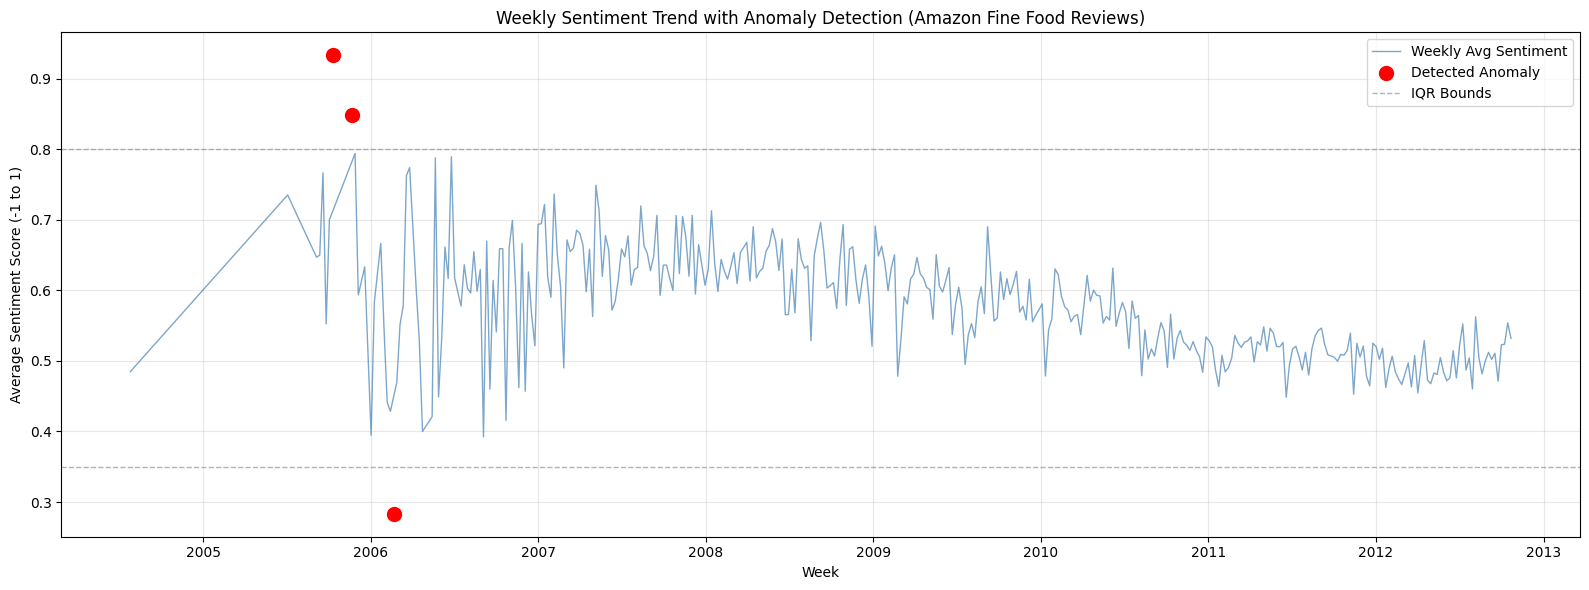

Grafik kaydedildi: weekly_sentiment_trend.png


In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 6))

# Normal haftaları çiz
normal_weeks = filtered_weekly_clean[~filtered_weekly_clean['is_anomaly']]
ax.plot(normal_weeks['week_start'], normal_weeks['avg_sentiment'], 
        color='steelblue', linewidth=1, alpha=0.7, label='Weekly Avg Sentiment')

# Anomalileri kırmızı noktalarla işaretle
ax.scatter(anomalies_clean['week_start'], anomalies_clean['avg_sentiment'],
           color='red', s=100, zorder=5, label='Detected Anomaly')

# IQR sınırlarını göster
ax.axhline(y=upper_c, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='IQR Bounds')
ax.axhline(y=lower_c, color='gray', linestyle='--', linewidth=1, alpha=0.6)

ax.set_xlabel('Week')
ax.set_ylabel('Average Sentiment Score (-1 to 1)')
ax.set_title('Weekly Sentiment Trend with Anomaly Detection (Amazon Fine Food Reviews)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/erenbey/amazon-fine-food-reviews/weekly_sentiment_trend.png', dpi=150)
plt.show()

print('Grafik kaydedildi: weekly_sentiment_trend.png')

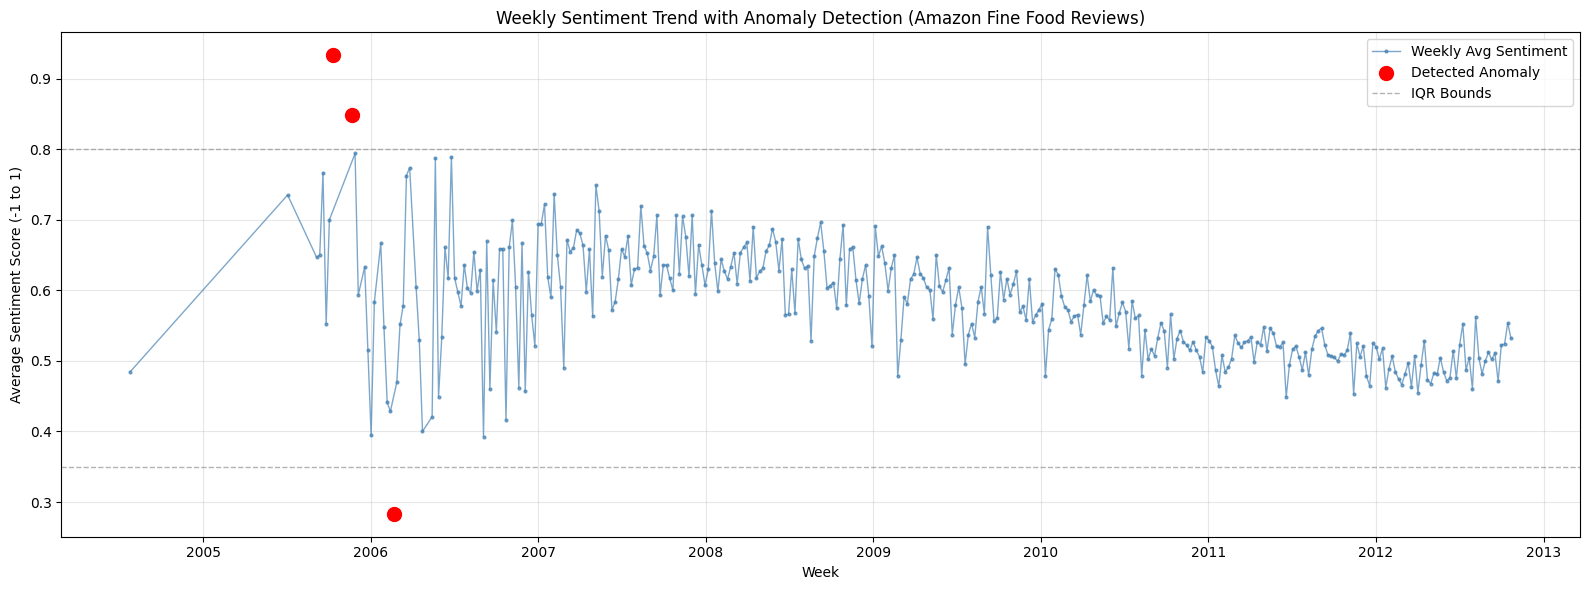

Grafik güncellendi ve kaydedildi.


In [28]:
fig, ax = plt.subplots(figsize=(16, 6))

# Normal haftaları çiz - marker eklendi
normal_weeks = filtered_weekly_clean[~filtered_weekly_clean['is_anomaly']]
ax.plot(normal_weeks['week_start'], normal_weeks['avg_sentiment'], 
        color='steelblue', linewidth=1, alpha=0.7, marker='.', markersize=4,
        label='Weekly Avg Sentiment')

# Anomalileri kırmızı noktalarla işaretle
ax.scatter(anomalies_clean['week_start'], anomalies_clean['avg_sentiment'],
           color='red', s=100, zorder=5, label='Detected Anomaly')

# IQR sınırlarını göster
ax.axhline(y=upper_c, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='IQR Bounds')
ax.axhline(y=lower_c, color='gray', linestyle='--', linewidth=1, alpha=0.6)

ax.set_xlabel('Week')
ax.set_ylabel('Average Sentiment Score (-1 to 1)')
ax.set_title('Weekly Sentiment Trend with Anomaly Detection (Amazon Fine Food Reviews)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/erenbey/amazon-fine-food-reviews/weekly_sentiment_trend.png', dpi=150)
plt.show()

print('Grafik güncellendi ve kaydedildi.')